# Importing & Setting up data from RGBXY

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import importlib
from PIL import Image
from skimage import color
# needs tidying up later

# First of all let's make sure the dithering package is importable
sys.path.insert(0, os.path.abspath('..'))

# for input/output of data
from dithering.io import load_palette, load_weights, load_image, reconstruct_additive, save_image

# For colour space conversions
from dithering.colour_space import *

# Display images at a reasonable size
plt.rcParams['figure.dpi'] = 120

In [2]:
# Setting our paths here (will change later, for now checkign with one image) 
IMAGE_PATH  = './data/sunset.jpg'
PALETTE_PATH = './data/sunset.jpg-automatic computed palette-modified.js'
WEIGHTS_PATH = './data/sunset.jpg-weights.js'
OUTPUT_DIR   = './output/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load everything
image   = load_image(IMAGE_PATH)
palette = load_palette(PALETTE_PATH)
weights = load_weights(WEIGHTS_PATH)

Loaded image with shape: (900, 1200, 3) (height=900, width=1200)
Loaded palette with 5 colours.
Loaded weights with shape: (900, 1200, 5) (height=900, width=1200, num_colours=5)


In [3]:
h, w = image.shape[:2]
num_colours = palette.shape[0]

print(f"Image shape:   {image.shape}  | value range: [{image.min():.3f}, {image.max():.3f}]")
print(f"Palette shape: {palette.shape} | value range: [{palette.min():.3f}, {palette.max():.3f}]")
print(f"Weights shape: {weights.shape} | value range: [{weights.min():.3f}, {weights.max():.3f}]")

# Weights should sum to ~1 per pixel
weight_sums = weights.sum(axis=2)
print(f"\nWeight sums per pixel - min: {weight_sums.min():.4f}, max: {weight_sums.max():.4f}")
print("(Should be close to 1.0 for all pixels)")

# Image and weights should have the same spatial dimensions
assert image.shape[:2] == weights.shape[:2], \
    f"Image and weights spatial dims don't match: {image.shape[:2]} vs {weights.shape[:2]}"
assert weights.shape[2] == palette.shape[0], \
    f"Number of weight channels ({weights.shape[2]}) doesn't match palette size ({palette.shape[0]})"

print("\nIf we reach this point without errors all checks passed!")

Image shape:   (900, 1200, 3)  | value range: [0.000, 1.000]
Palette shape: (5, 3) | value range: [0.000, 1.000]
Weights shape: (900, 1200, 5) | value range: [0.000, 1.000]

Weight sums per pixel - min: 0.9922, max: 1.0078
(Should be close to 1.0 for all pixels)

If we reach this point without errors all checks passed!


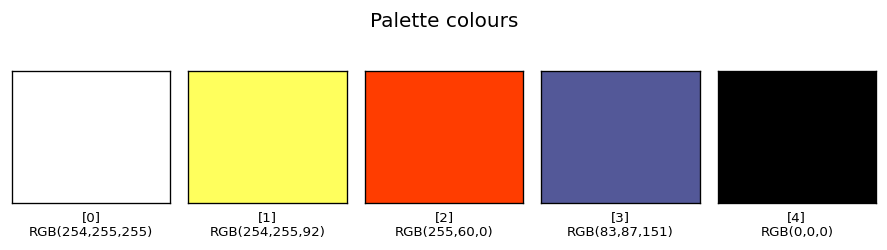

In [4]:
# Let's also visualize the palette colours to sanity check them
fig, axes = plt.subplots(1, num_colours, figsize=(num_colours * 1.5, 2))
if num_colours == 1:
    axes = [axes]

# Show each palette colour as a solid block (aka swatch)
for i, (ax, colour) in enumerate(zip(axes, palette)):
    ax.set_facecolor(colour)
    ax.set_xticks([])
    ax.set_yticks([])
    rgb_255 = (colour * 255).astype(int)
    ax.set_xlabel(f'[{i}]\nRGB({rgb_255[0]},{rgb_255[1]},{rgb_255[2]})', fontsize=8)

fig.suptitle('Palette colours', y=1.02)
plt.tight_layout()
plt.show()

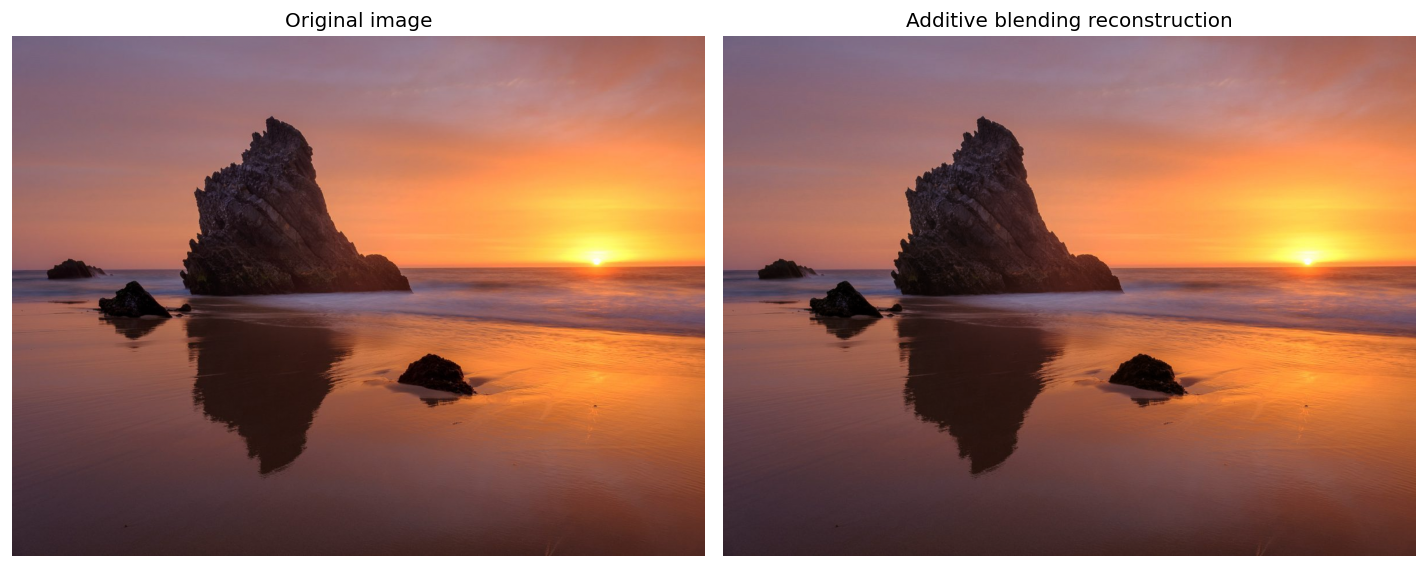

Saved image to ./output/sunset_additive.png


In [5]:
# in order to reconstruct the image we can do a weighted sum of the palette colours using the mixing weights
additive = reconstruct_additive(weights, palette)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image)
axes[0].set_title('Original image')
axes[0].axis('off')

axes[1].imshow(additive)
axes[1].set_title('Additive blending reconstruction')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Save for later comparison
save_image(additive, OUTPUT_DIR + 'sunset_additive.png')

# Colour Space sanity checks

Test 1 - Round-trip conversion test:
  Original RGB:              [0.5  0.25 0.75]
  RGB → CIELAB → RGB:        [0.5  0.25 0.75]
  RGB → CIExyY → RGB:        [0.5  0.25 0.75]
  CIELAB round-trip error:   2.78e-16
  CIExyY round-trip error:   3.51e-08
(Both errors should be close to 0)


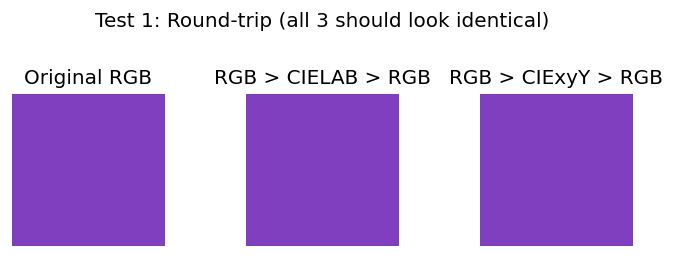

In [6]:
# Test 1: round-trip conversion, for a single pixel to CIELAB & CIExyY and back
test_pixel_rgb = np.array([0.5, 0.25, 0.75])  # Example RGB pixel

# RGB --> CIELAB --> RGB
recovered_cielab = lab_to_rgb(rgb_to_lab(test_pixel_rgb))
# RGB --> CIExyY --> RGB
recovered_ciexyY = xyY_to_rgb(rgb_to_xyY(test_pixel_rgb)) 

print("Test 1 - Round-trip conversion test:")
print(f"  Original RGB:              {test_pixel_rgb}")
print(f"  RGB → CIELAB → RGB:        {recovered_cielab.round(6)}")
print(f"  RGB → CIExyY → RGB:        {recovered_ciexyY.round(6)}")
print(f"  CIELAB round-trip error:   {np.abs(test_pixel_rgb - recovered_cielab).max():.2e}")
print(f"  CIExyY round-trip error:   {np.abs(test_pixel_rgb - recovered_ciexyY).max():.2e}")
print("(Both errors should be close to 0)")

# and now to visualize it
# all three should look identical since they all represent the same colour
fig, axes = plt.subplots(1, 3, figsize=(6, 2))

axes[0].imshow(np.array([[test_pixel_rgb]]))
axes[0].set_title('Original RGB')
axes[0].axis('off')

axes[1].imshow(np.array([[recovered_cielab]]))
axes[1].set_title('RGB > CIELAB > RGB')
axes[1].axis('off')

axes[2].imshow(np.array([[recovered_ciexyY]]))
axes[2].set_title('RGB > CIExyY > RGB')
axes[2].axis('off')

plt.suptitle('Test 1: Round-trip (all 3 should look identical)', y=1.05)
plt.tight_layout()
plt.show()

In [7]:
# Test 2: known values, pure black & white to CIELAB & CIExyY and back
test_pixel_rgb = np.array([0.5, 0.25, 0.75])  # Example RGB pixel

# RGB = [1, 0, 0], CIELAB = [1, 0, 0], CIExyY = [1/3, 1/3, 1]
white = np.array([1.0, 1.0, 1.0])
# RGB = [0, 0, 0], CIELAB = [0, 0, 0], CIExyY = [..., ..., 0]
black = np.array([0.0, 0.0, 0.0])

print("\nTest 2 - Known value test (CIELAB):")
print(f"  White RGB {white} > CIELAB {rgb_to_lab(white).round(4)}")
print(f"  Black RGB {black} > CIELAB {rgb_to_lab(black).round(4)}")
print("  (White should be ~[100, 0, 0], black should be ~[0, 0, 0])")

print("\nTest 2 - Known value test (CIE xyY):")
print(f"  White RGB {white} > CIExyY {rgb_to_xyY(white).round(4)}")
print(f"  Black RGB {black} > CIExyY {rgb_to_xyY(black).round(4)}")
print("  (White should be ~[0.3127, 0.3290, 1] (D65 explanation - elaborated on report), black should be ~[0, 0, 0])")


Test 2 - Known value test (CIELAB):
  White RGB [1. 1. 1.] > CIELAB [ 1.0e+02 -2.5e-03  4.7e-03]
  Black RGB [0. 0. 0.] > CIELAB [0. 0. 0.]
  (White should be ~[100, 0, 0], black should be ~[0, 0, 0])

Test 2 - Known value test (CIE xyY):
  White RGB [1. 1. 1.] > CIExyY [0.3127 0.329  1.    ]
  Black RGB [0. 0. 0.] > CIExyY [0. 0. 0.]
  (White should be ~[0.3127, 0.3290, 1] (D65 explanation - elaborated on report), black should be ~[0, 0, 0])



Test 3 -Palette colours visualized in each colour space:


RGB                CIELAB               CIE xyY                
            R      G      B       L      a      b       x       y       Y
Colour                                                                   
0       1.000  1.000  1.000  100.00  -0.00   0.00  0.3127  0.3290  1.0000
1       1.000  1.000  0.363   97.46 -19.00  74.52  0.4014  0.4757  0.9357
2       1.000  0.237  0.000   56.64  70.41  68.54  0.6134  0.3512  0.2456
3       0.326  0.344  0.595   39.68  15.62 -35.60  0.2319  0.2019  0.1106
4       0.000  0.000  0.000    0.00   0.00   0.00  0.0000  0.0000  0.0000

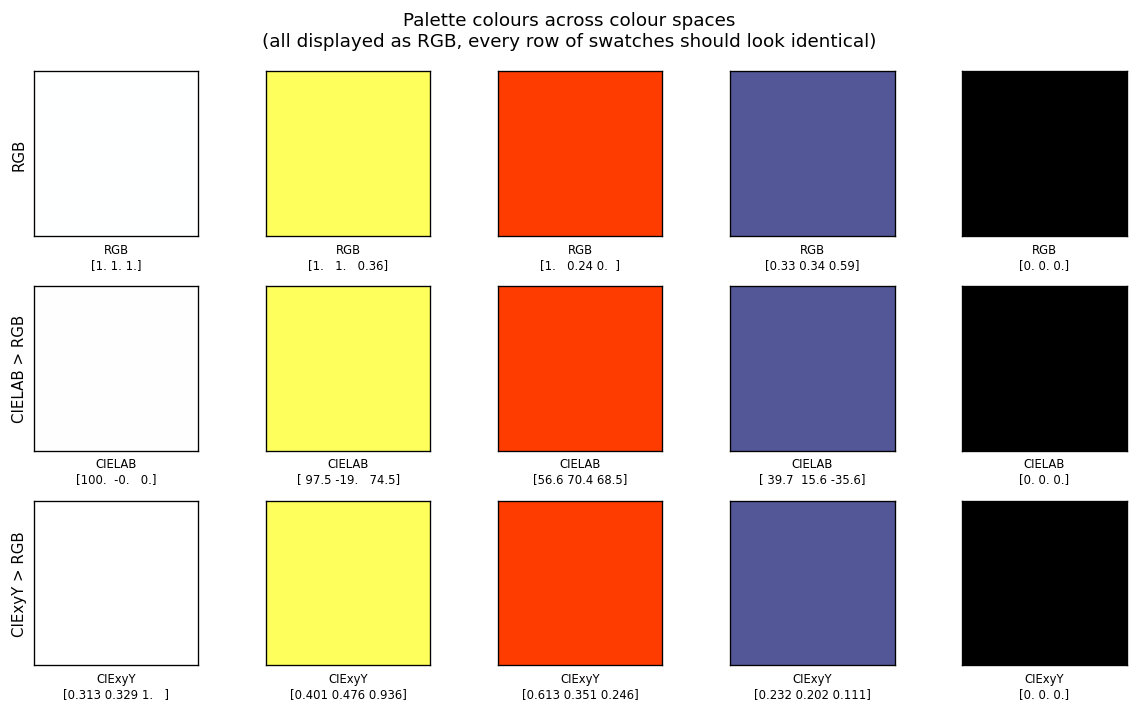

In [8]:
# Test 3: visualise a palette in each color space
print("\nTest 3 -Palette colours visualized in each colour space:")

# first t o calculate and print the values in each colour space in a table
rows = []
for i, colour in enumerate(palette):
    lab = rgb_to_lab(colour)
    xyy = rgb_to_xyY(colour)
    rows.append([
        round(colour[0], 3), round(colour[1], 3), round(colour[2], 3),
        round(lab[0], 2),    round(lab[1], 2),    round(lab[2], 2),
        round(xyy[0], 4),    round(xyy[1], 4),    round(xyy[2], 4),
    ])

columns = pd.MultiIndex.from_tuples([
    ('RGB',    'R'),
    ('RGB',    'G'),
    ('RGB',    'B'),
    ('CIELAB', 'L'),
    ('CIELAB', 'a'),
    ('CIELAB', 'b'),
    ('CIE xyY', 'x'),
    ('CIE xyY', 'y'),
    ('CIE xyY', 'Y'),
])

df = pd.DataFrame(rows, columns=columns)
df.index.name = 'Colour'
display(df)
    
# now we can visualise the palette in RGB, CIELAB, and CIExyY (all displayed as RGB swatches)
fig, axes = plt.subplots(3, len(palette), figsize=(len(palette) * 2, 6))

row_labels = ['RGB', 'CIELAB > RGB', 'CIExyY > RGB']

for i, colour in enumerate(palette):
    # row 0: original RGB
    axes[0, i].imshow(np.array([[colour]]))
    axes[0, i].set_xlabel(f'RGB\n{colour.round(2)}', fontsize=7)
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

    # row 1: convert to CIELAB and back to RGB for display
    lab = rgb_to_lab(colour)
    axes[1, i].imshow(np.array([[np.clip(lab_to_rgb(lab), 0, 1)]]))
    axes[1, i].set_xlabel(f'CIELAB\n{lab.round(1)}', fontsize=7)
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

    # row 2: convert to CIExyY and back to RGB for display
    xyy = rgb_to_xyY(colour)
    axes[2, i].imshow(np.array([[np.clip(xyY_to_rgb(xyy), 0, 1)]]))
    axes[2, i].set_xlabel(f'CIExyY\n{xyy.round(3)}', fontsize=7)
    axes[2, i].set_xticks([])
    axes[2, i].set_yticks([])

for i, label in enumerate(row_labels):
    axes[i, 0].set_ylabel(label, fontsize=9)

fig.suptitle('Palette colours across colour spaces\n(all displayed as RGB, every row of swatches should look identical)', fontsize=11)
plt.tight_layout()
plt.show()

# Floyd-Steinberg Dithering

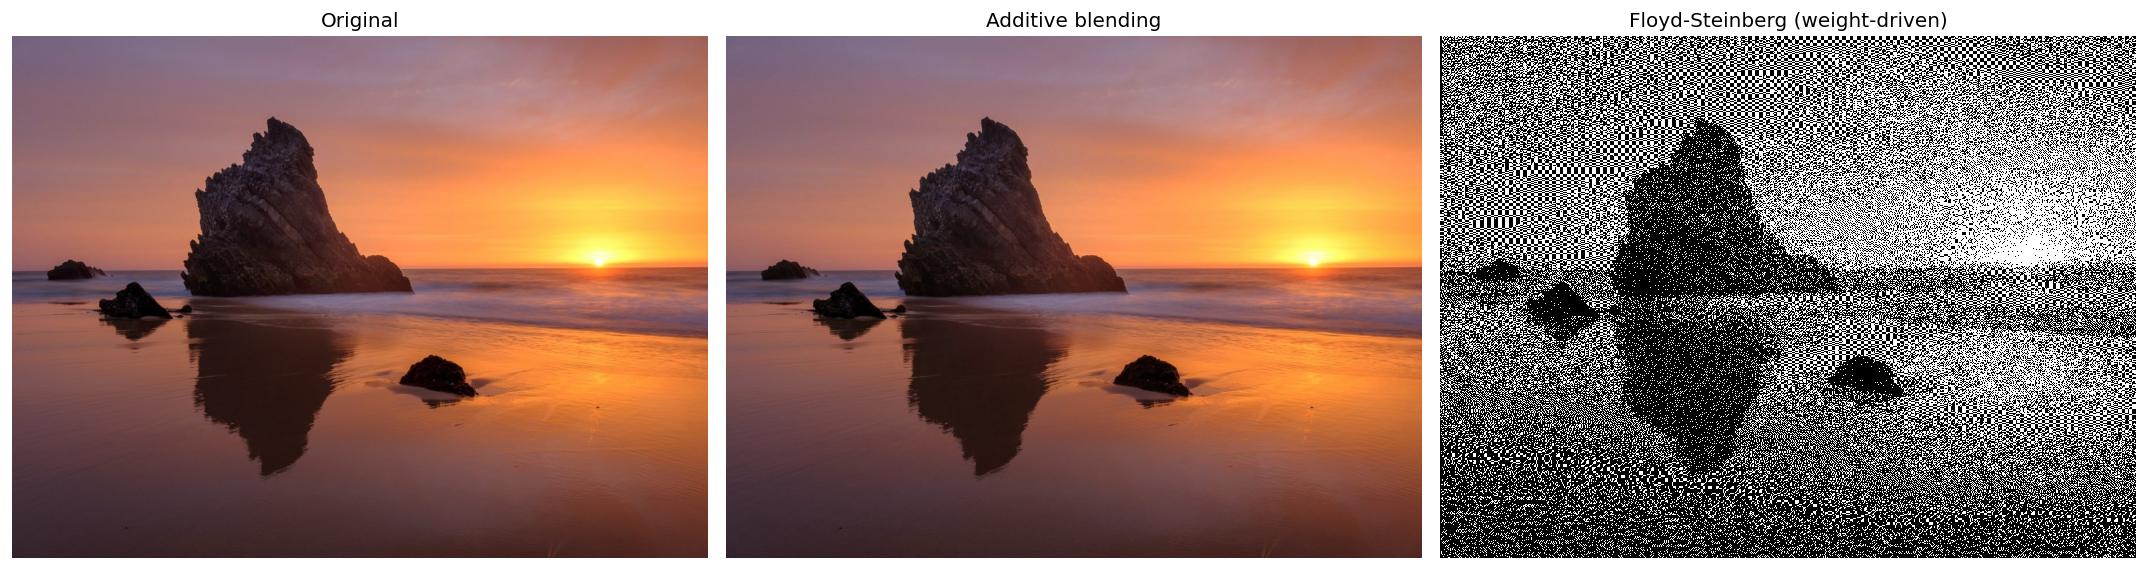

In [9]:
from dithering.floyd_steinberg import to_grayscale, floyd_steinberg_grayscale
import dithering.floyd_steinberg as fs

# Convert to grayscale
gray = to_grayscale(image)

# Apply basic dithering
dithered_bw = floyd_steinberg_grayscale(gray)

# Display
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

axes[2].imshow(dithered_bw, cmap='gray', interpolation='nearest')
axes[2].set_title('Floyd-Steinberg (black & white)')
axes[2].axis('off')

# plt.tight_layout()
# plt.show()
axes[1].imshow(additive)
axes[1].set_title('Additive blending')
axes[1].axis('off')
axes[2].set_title('Floyd-Steinberg (weight-driven)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

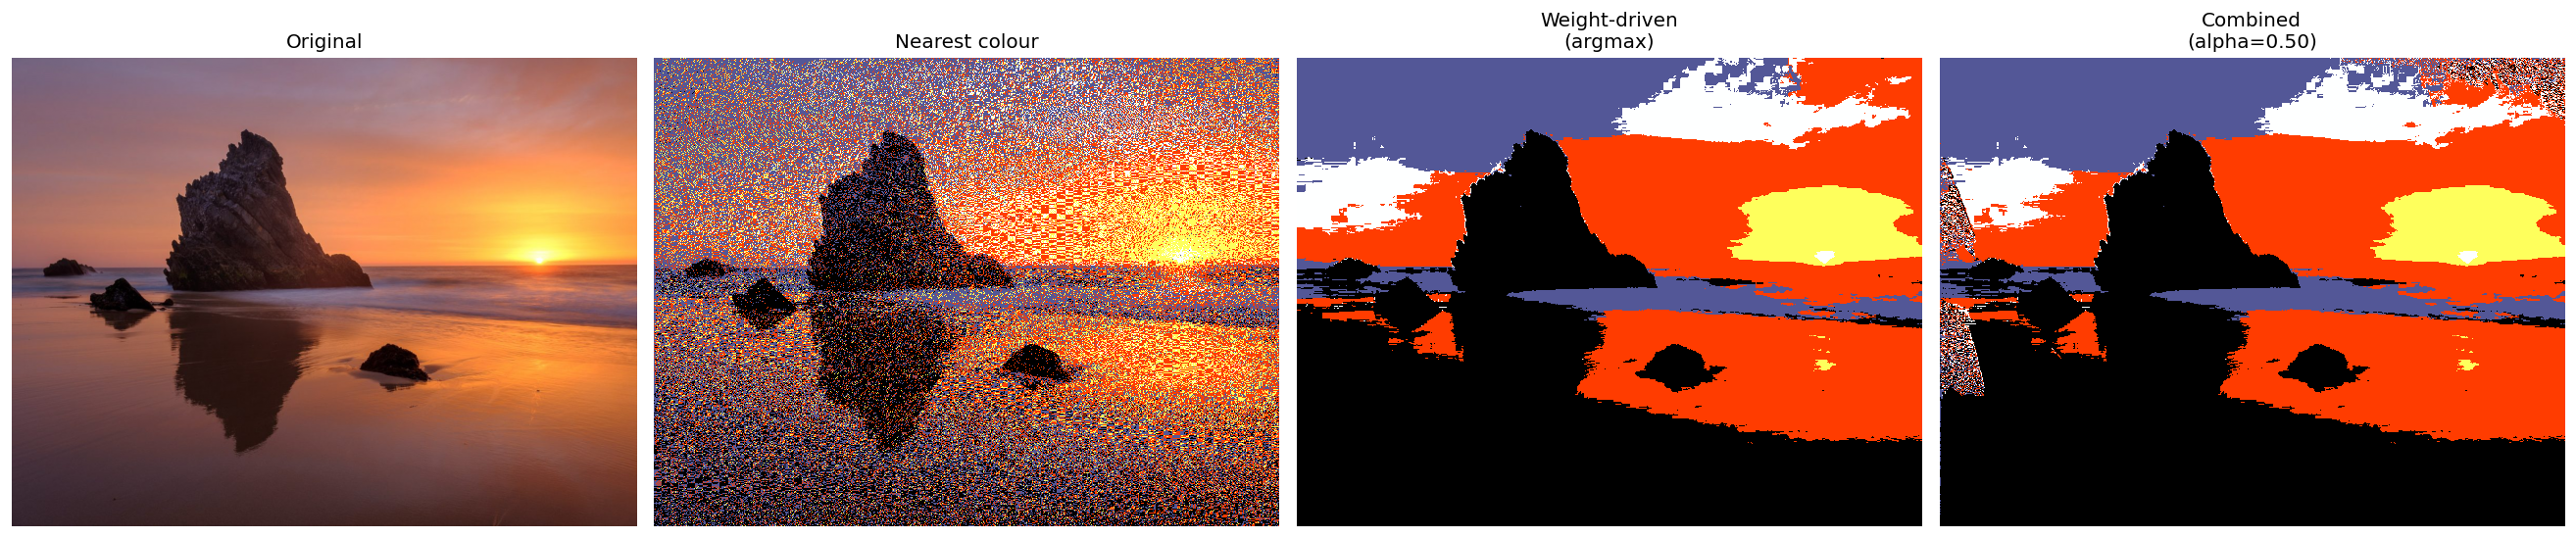

In [10]:
from dithering.floyd_steinberg import floyd_steinberg_nearest, floyd_steinberg_weight_driven, floyd_steinberg_weighted_nearest

# Set a value
alpha = 0.5

# Run all three
dithered_nearest  = floyd_steinberg_nearest(image, palette)
dithered_weights  = floyd_steinberg_weight_driven(image, palette, weights)
dithered_combined = floyd_steinberg_weighted_nearest(image, palette, weights, alpha)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(dithered_nearest, interpolation='nearest')
axes[1].set_title('Nearest colour')
axes[1].axis('off')

axes[2].imshow(dithered_weights, interpolation='nearest')
axes[2].set_title('Weight-driven\n(argmax)')
axes[2].axis('off')

axes[3].imshow(dithered_combined, interpolation='nearest')
axes[3].set_title(f'Combined\n(alpha={alpha:.2f})')
axes[3].axis('off')

plt.tight_layout()
plt.show()